In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [73]:
df = pd.read_csv(
    "/Users/tsantaloic/Desktop/Projet_05_AIA02/data/processed/amazon_reviews_cleaned.csv",
    parse_dates=["timestamp"]
)

df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category,user_id_enc,item_id_enc,rating_norm
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-07-18 22:58:37.948,0,True,Electronics,1456,15167,-1.239889
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-06-20 18:42:29.731,0,True,Electronics,1456,13689,-3.037525
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:23:37.534,0,True,Electronics,1456,10383,0.557747
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,2010-11-20 18:41:35.000,18,True,Electronics,2248,5393,0.557747
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,2023-02-17 02:39:41.238,0,True,Electronics,1892,12523,0.557747


In [74]:
# Nombre d’interactions & produits distincts
user_volume = df.groupby("user_id").agg(
    nb_interactions=("parent_asin", "count"),
    nb_products=("parent_asin", "nunique")
).reset_index()

user_volume.head()

# nb_interactions = niveau d’activité global
#nb_products = diversité des achats

,user_id,nb_interactions,nb_products
0,AE225Z2VRWT6GPTOMA4H4O3H2KVQ,1,1
1,AE23YCERVBZ7ABKTESKSSXYTLYRA,1,1
2,AE246WPAV4HBLUOOOKTECTYQ7ZPA,2,2
3,AE25NQAZI3725GZIL5FS52ZIKWKQ,9,9
4,AE26ICWKMFJEHDH5VDX4W42H2NMA,3,3


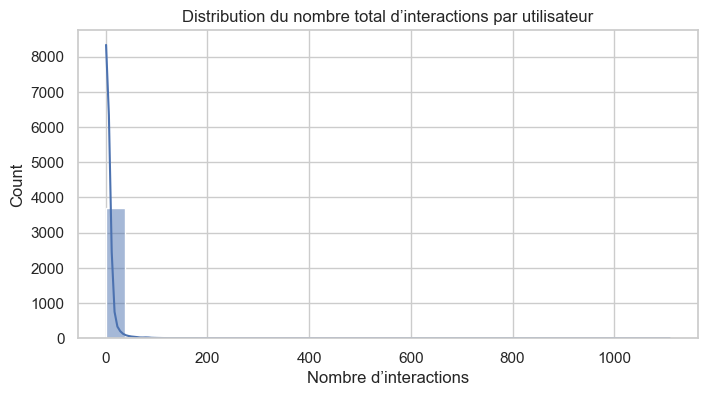

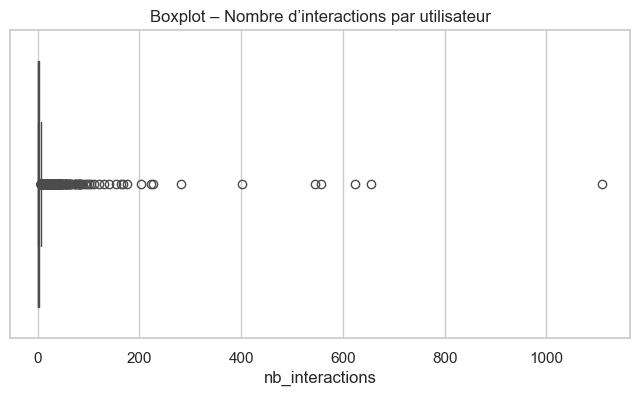

In [75]:
# Nombre total d’interactions par utilisateur
plt.figure(figsize=(8,4))
sns.histplot(user_volume["nb_interactions"], bins=30, kde=True)
plt.title("Distribution du nombre total d’interactions par utilisateur")
plt.xlabel("Nombre d’interactions")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=user_volume["nb_interactions"])
plt.title("Boxplot – Nombre d’interactions par utilisateur")
plt.show()

#majorité d’utilisateurs peu actifs
#quelques utilisateurs très actifs (long tail)

In [76]:
# Fréquence de reviews (par mois)

df["year_month"] = df["timestamp"].dt.to_period("M")
reviews_per_month = (
    df.groupby(["user_id", "year_month"])
      .size()
      .groupby("user_id")
      .mean()
      .rename("avg_reviews_per_month")
      .reset_index()
)

reviews_per_month.head()


,user_id,avg_reviews_per_month
0,AE225Z2VRWT6GPTOMA4H4O3H2KVQ,1.00
1,AE23YCERVBZ7ABKTESKSSXYTLYRA,1.00
2,AE246WPAV4HBLUOOOKTECTYQ7ZPA,1.00
3,AE25NQAZI3725GZIL5FS52ZIKWKQ,2.25
4,AE26ICWKMFJEHDH5VDX4W42H2NMA,1.50


In [77]:
user_volume.columns
# ou
print(user_volume.columns.tolist())


['user_id', 'nb_interactions', 'nb_products']


In [78]:
user_volume = user_volume.merge(
    reviews_per_month,
    on="user_id",
    how="left"
)


In [79]:
print(user_volume.columns.tolist())


['user_id', 'nb_interactions', 'nb_products', 'avg_reviews_per_month']


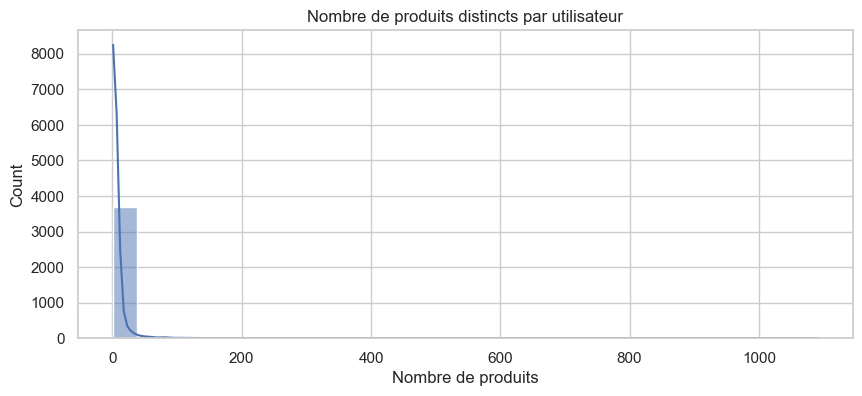

In [80]:
#Nombre de produits distincts par utilisateur
plt.figure(figsize=(10,4))
sns.histplot(user_volume["nb_products"], bins=30, kde=True)
plt.title("Nombre de produits distincts par utilisateur")
plt.xlabel("Nombre de produits")
plt.show()


In [81]:
#Récence (temps depuis la dernière interaction)
reference_date = df["timestamp"].max()

last_interaction = (
    df.groupby("user_id")["timestamp"]
      .max()
      .reset_index(name="last_interaction")
)

last_interaction["recency_days"] = (
    reference_date - last_interaction["last_interaction"]
).dt.days

last_interaction.head()

# faible récence = utilisateur actif récemment
#forte récence = utilisateur inactif

,user_id,last_interaction,recency_days
0,AE225Z2VRWT6GPTOMA4H4O3H2KVQ,2018-03-03 01:11:55.541,1840
1,AE23YCERVBZ7ABKTESKSSXYTLYRA,2009-12-15 14:48:27.000,4840
2,AE246WPAV4HBLUOOOKTECTYQ7ZPA,2023-03-16 11:09:16.918,1
3,AE25NQAZI3725GZIL5FS52ZIKWKQ,2019-11-14 17:30:08.565,1219
4,AE26ICWKMFJEHDH5VDX4W42H2NMA,2021-07-29 13:24:38.824,596


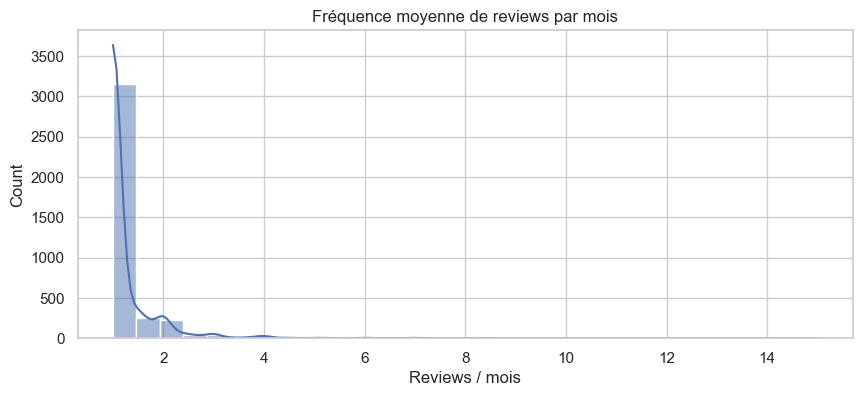

In [82]:
# Fréquence moyenne de reviews par mois
plt.figure(figsize=(10,4))
sns.histplot(user_volume["avg_reviews_per_month"], bins=30, kde=True)
plt.title("Fréquence moyenne de reviews par mois")
plt.xlabel("Reviews / mois")
plt.show()


In [83]:
user_volume.columns
# ou
print(user_volume.columns.tolist())


['user_id', 'nb_interactions', 'nb_products', 'avg_reviews_per_month']


In [84]:
# Activité récente
def count_recent_interactions(days):
    cutoff = reference_date - pd.Timedelta(days=days)
    return (
        df[df["timestamp"] >= cutoff]
        .groupby("user_id")
        .size()
        .rename(f"interactions_last_{days}_days")
    )

recent_30 = count_recent_interactions(30)
recent_90 = count_recent_interactions(90)


In [85]:
recent_activity = pd.concat([recent_30, recent_90], axis=1).fillna(0).reset_index()
recent_activity.head()


,user_id,interactions_last_30_days,interactions_last_90_days
0,AE246WPAV4HBLUOOOKTECTYQ7ZPA,1.0,1
1,AE3U73QGVDLZUA2DSACCVDCYAY6Q,4.0,7
2,AE4KVNO5P6N6SP6CQTZTIDHEAWFQ,1.0,2
3,AE4L2LH55JNFCLHFXFC7YOEQSBIA,1.0,1
4,AE72A3F2N3PVD4CJM527Z4N6CN2A,1.0,1


In [86]:
#Saisonnalité
df["month"] = df["timestamp"].dt.month


In [87]:
monthly_activity = (
    df.groupby(["user_id", "month"])
      .size()
      .unstack(fill_value=0)
)

monthly_activity.head()


month,1,2,3,4,5,6,7,8,9,10,11,12
user_id,,,,,,,,,,,,
AE225Z2VRWT6GPTOMA4H4O3H2KVQ,0,0,1,0,0,0,0,0,0,0,0,0
AE23YCERVBZ7ABKTESKSSXYTLYRA,0,0,0,0,0,0,0,0,0,0,0,1
AE246WPAV4HBLUOOOKTECTYQ7ZPA,0,0,1,0,0,0,1,0,0,0,0,0
AE25NQAZI3725GZIL5FS52ZIKWKQ,0,4,0,0,0,3,0,0,0,0,2,0
AE26ICWKMFJEHDH5VDX4W42H2NMA,0,0,0,0,0,0,1,0,0,0,2,0


In [92]:
monthly_activity.columns
monthly_activity.head()


month,1,2,3,4,5,6,7,8,9,10,11,12,max_monthly_interactions
user_id,,,,,,,,,,,,,
AE225Z2VRWT6GPTOMA4H4O3H2KVQ,0,0,1,0,0,0,0,0,0,0,0,0,1
AE23YCERVBZ7ABKTESKSSXYTLYRA,0,0,0,0,0,0,0,0,0,0,0,1,1
AE246WPAV4HBLUOOOKTECTYQ7ZPA,0,0,1,0,0,0,1,0,0,0,0,0,1
AE25NQAZI3725GZIL5FS52ZIKWKQ,0,4,0,0,0,3,0,0,0,0,2,0,4
AE26ICWKMFJEHDH5VDX4W42H2NMA,0,0,0,0,0,0,1,0,0,0,2,0,2


In [97]:
monthly_activity.columns.tolist()


[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 'max_monthly_interactions',
 'most_active_month']

In [99]:
month_cols = list(range(1, 13))  # colonnes mois = 1 à 12

monthly_activity["max_monthly_interactions"] = monthly_activity[month_cols].max(axis=1)
monthly_activity["most_active_month"] = monthly_activity[month_cols].idxmax(axis=1)

monthly_activity[["most_active_month", "max_monthly_interactions"]].head()



month,most_active_month,max_monthly_interactions
user_id,,
AE225Z2VRWT6GPTOMA4H4O3H2KVQ,3,1
AE23YCERVBZ7ABKTESKSSXYTLYRA,12,1
AE246WPAV4HBLUOOOKTECTYQ7ZPA,3,1
AE25NQAZI3725GZIL5FS52ZIKWKQ,2,4
AE26ICWKMFJEHDH5VDX4W42H2NMA,11,2


In [100]:
user_volume_recency = (
    user_volume
    .merge(reviews_per_month, on="user_id", how="left")
    .merge(last_interaction[["user_id", "recency_days"]], on="user_id", how="left")
    .merge(recent_activity, on="user_id", how="left")
    .merge(
        monthly_activity[["most_active_month", "max_monthly_interactions"]],
        left_on="user_id",
        right_index=True,
        how="left"
    )
)

user_volume_recency.head()


,user_id,nb_interactions,nb_products,avg_reviews_per_month_x,avg_reviews_per_month_y,recency_days,interactions_last_30_days,interactions_last_90_days,most_active_month,max_monthly_interactions
0,AE225Z2VRWT6GPTOMA4H4O3H2KVQ,1,1,1.00,1.00,1840,NaN,NaN,3,1
1,AE23YCERVBZ7ABKTESKSSXYTLYRA,1,1,1.00,1.00,4840,NaN,NaN,12,1
2,AE246WPAV4HBLUOOOKTECTYQ7ZPA,2,2,1.00,1.00,1,1.0,1.0,3,1
3,AE25NQAZI3725GZIL5FS52ZIKWKQ,9,9,2.25,2.25,1219,NaN,NaN,2,4
4,AE26ICWKMFJEHDH5VDX4W42H2NMA,3,3,1.50,1.50,596,NaN,NaN,11,2


In [102]:
print(user_volume.columns.tolist())
[c for c in user_volume.columns if "rec" in c.lower() or "day" in c.lower() or "last" in c.lower()]


['user_id', 'nb_interactions', 'nb_products', 'avg_reviews_per_month']


[]

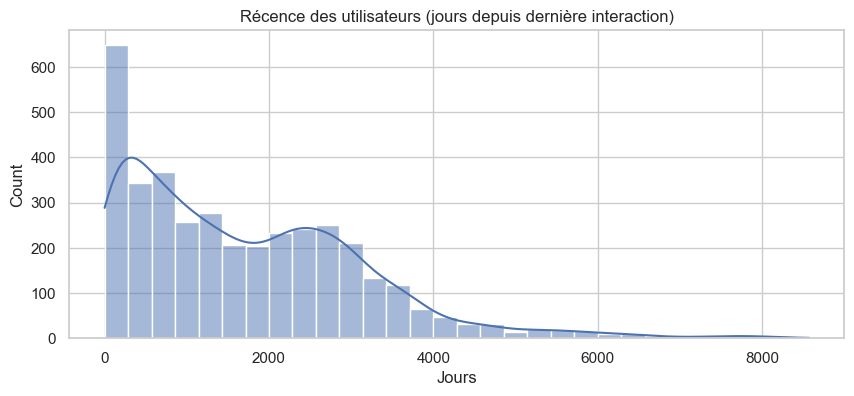

In [108]:

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Dernière date par user
last_interaction = (
    df.groupby("user_id")["timestamp"]
      .max()
      .rename("last_interaction")
      .reset_index()
)

# Recency = nb de jours depuis la dernière interaction
ref_date = df["timestamp"].max()
last_interaction["recency_days"] = (ref_date - last_interaction["last_interaction"]).dt.days

user_volume = user_volume.merge(
    last_interaction[["user_id", "recency_days"]],
    on="user_id",
    how="left"
)
plt.figure(figsize=(10,4))
sns.histplot(user_volume["recency_days"].dropna(), bins=30, kde=True)
plt.title("Récence des utilisateurs (jours depuis dernière interaction)")
plt.xlabel("Jours")
plt.show()



In [106]:
df[["user_id", "timestamp"]].head()
df["timestamp"].dtype
df["timestamp"].isna().mean()


np.float64(0.0)

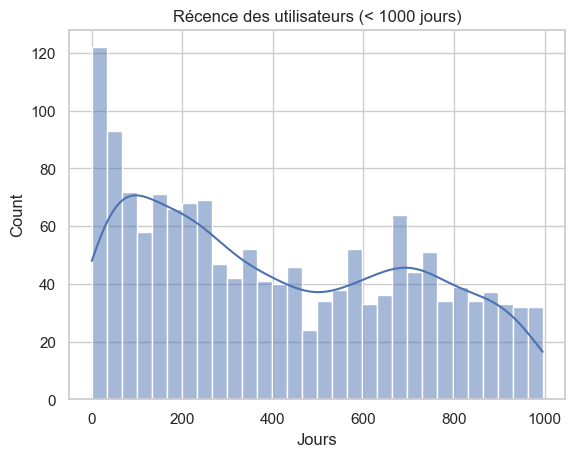

In [109]:
sns.histplot(
    user_volume.loc[user_volume["recency_days"] < 1000, "recency_days"],
    bins=30,
    kde=True
)
plt.title("Récence des utilisateurs (< 1000 jours)")
plt.xlabel("Jours")
plt.show()


In [111]:
import pandas as pd

# sécurité : timestamp en datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

ref_date = df["timestamp"].max()

cut_30 = ref_date - pd.Timedelta(days=30)
cut_90 = ref_date - pd.Timedelta(days=90)

inter_30 = (
    df.loc[df["timestamp"] >= cut_30]
      .groupby("user_id")
      .size()
      .rename("interactions_last_30_days")
      .reset_index()
)

inter_90 = (
    df.loc[df["timestamp"] >= cut_90]
      .groupby("user_id")
      .size()
      .rename("interactions_last_90_days")
      .reset_index()
)


In [112]:
user_volume = user_volume.merge(inter_30, on="user_id", how="left")
user_volume = user_volume.merge(inter_90, on="user_id", how="left")

user_volume[["interactions_last_30_days", "interactions_last_90_days"]] = (
    user_volume[["interactions_last_30_days", "interactions_last_90_days"]].fillna(0).astype(int)
)
user_volume[["user_id", "interactions_last_30_days", "interactions_last_90_days"]].head()


,user_id,interactions_last_30_days,interactions_last_90_days
0,AE225Z2VRWT6GPTOMA4H4O3H2KVQ,0,0
1,AE23YCERVBZ7ABKTESKSSXYTLYRA,0,0
2,AE246WPAV4HBLUOOOKTECTYQ7ZPA,1,1
3,AE25NQAZI3725GZIL5FS52ZIKWKQ,0,0
4,AE26ICWKMFJEHDH5VDX4W42H2NMA,0,0


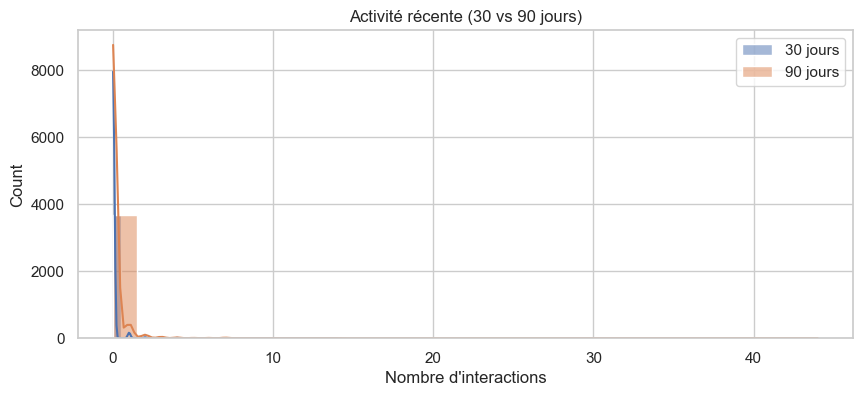

In [113]:
plt.figure(figsize=(10,4))
sns.histplot(user_volume["interactions_last_30_days"], label="30 jours", kde=True, bins=30)
sns.histplot(user_volume["interactions_last_90_days"], label="90 jours", kde=True, bins=30)
plt.title("Activité récente (30 vs 90 jours)")
plt.xlabel("Nombre d'interactions")
plt.legend()
plt.show()


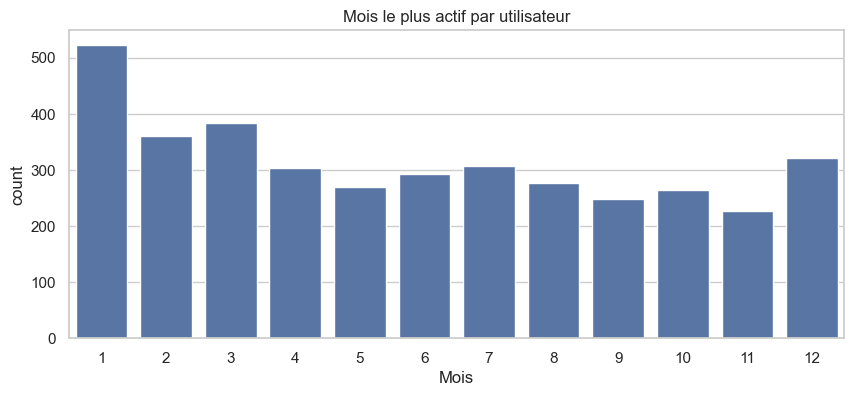

In [114]:
plt.figure(figsize=(10,4))
sns.countplot(x=user_volume_recency["most_active_month"])
plt.title("Mois le plus actif par utilisateur")
plt.xlabel("Mois")
plt.show()


In [117]:
df["timestamp"].dtype


dtype('<M8[ns]')

In [118]:
ref_date = df["timestamp"].max()

inter_30 = (
    df[df["timestamp"] >= ref_date - pd.Timedelta(days=30)]
    .groupby("user_id")
    .size()
    .rename("interactions_last_30_days")
    .reset_index()
)

inter_90 = (
    df[df["timestamp"] >= ref_date - pd.Timedelta(days=90)]
    .groupby("user_id")
    .size()
    .rename("interactions_last_90_days")
    .reset_index()
)


In [116]:
df.to_csv("../data/processed/user_volume_recency.csv", index=False)